**Procesamiento de Imágenes   ITSE - Instituto Tecnológico de Santiago del Estero**\

# Top Hat Filter in Image Processing


In [1]:
!pip install -q gdown

In [2]:
#https://drive.google.com/file/d/1NOlZD_Z7b6HxjDzUozIlssJ-FRZcKbNR/view?usp=sharing
file_id = "1NOlZD_Z7b6HxjDzUozIlssJ-FRZcKbNR"
import gdown

# Descargar la imagen
gdown.download(
    id=file_id,
    output="frutos.png",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1NOlZD_Z7b6HxjDzUozIlssJ-FRZcKbNR
To: /content/frutos.png
100%|██████████| 352k/352k [00:00<00:00, 16.3MB/s]


'frutos.png'

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

(767, 760)


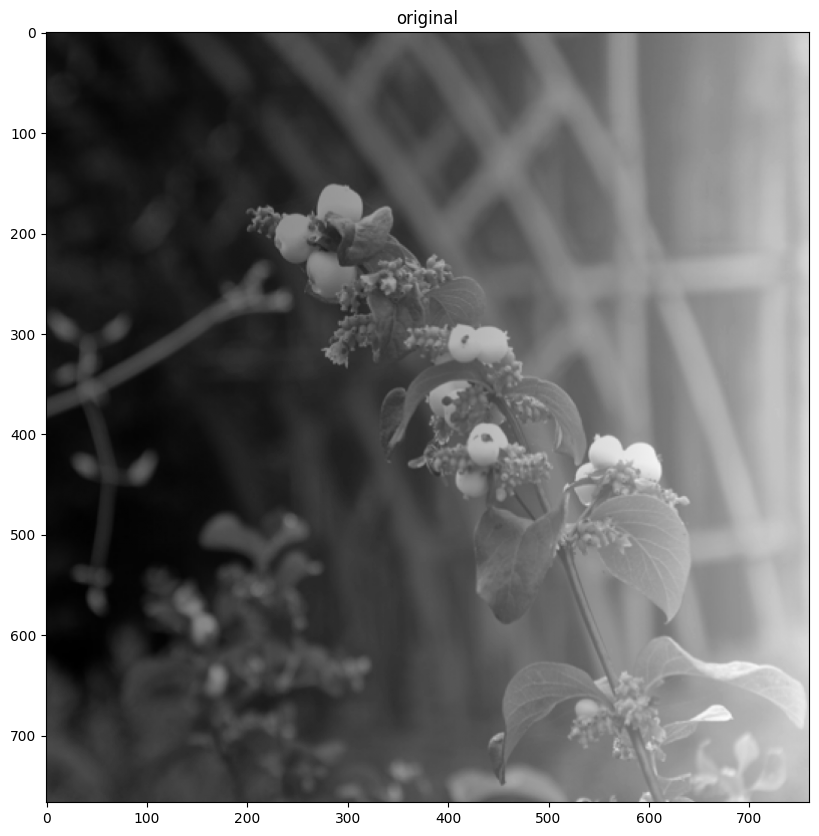

In [4]:
X = cv2.imread('frutos.png',0)
print(X.shape)
plt.figure(figsize=(10,10))
plt.imshow(X,cmap='gray')
plt.title('original')
plt.show()

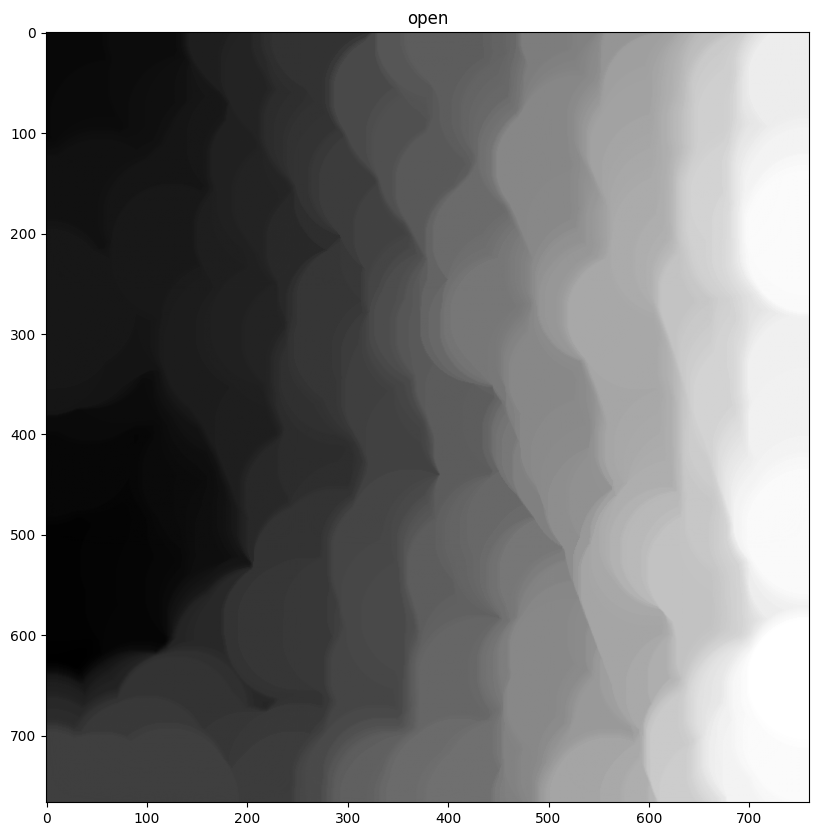

In [5]:
n = 120

Xe = cv2.morphologyEx(X, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n,n)))



plt.figure(figsize=(10,10))
plt.imshow(Xe,cmap='gray')
plt.title('open')
plt.show()

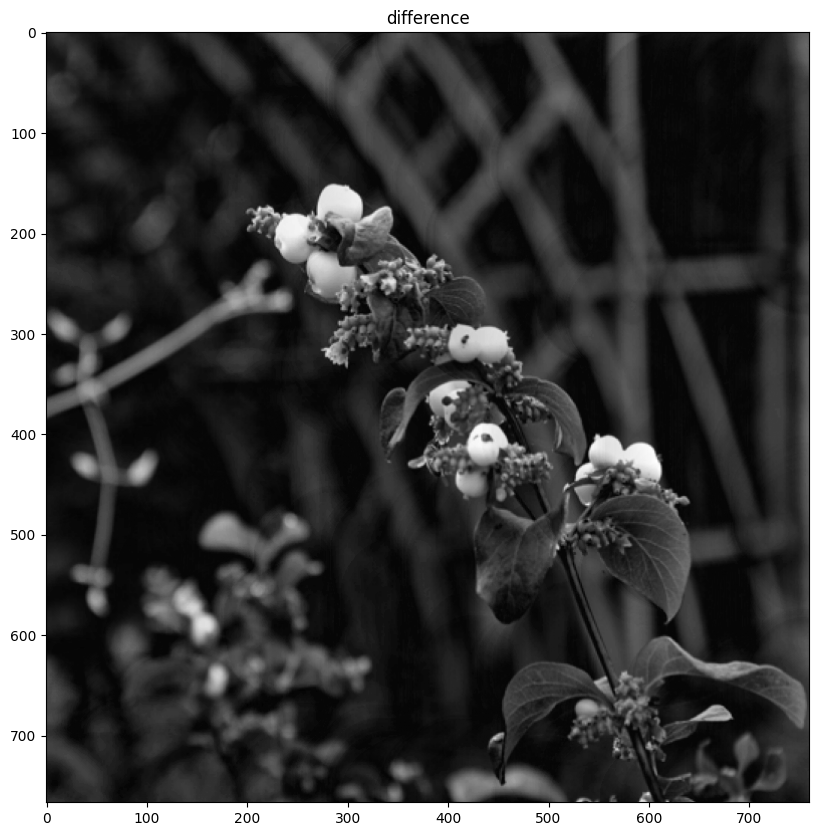

In [6]:
Xd = X.astype(float) -Xe.astype(float)
plt.figure(figsize=(10,10))
plt.imshow(Xd,cmap='gray')
plt.title('difference')
plt.show()


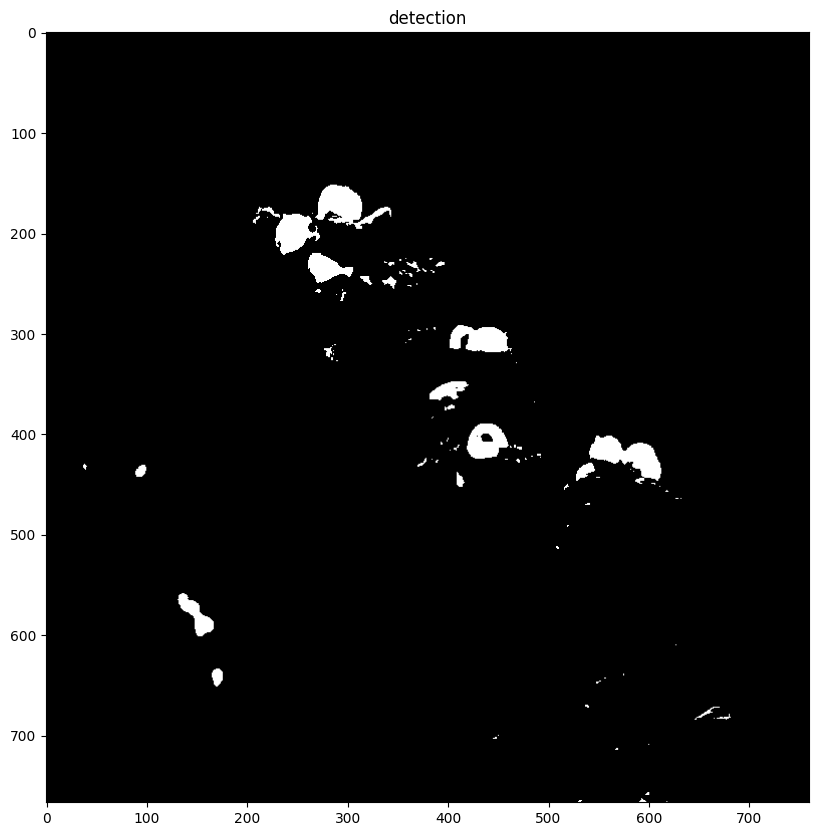

In [7]:
th = 80
D = Xd>th
plt.figure(figsize=(10,10))
plt.imshow(D,cmap='gray')
plt.title('detection')
plt.show()



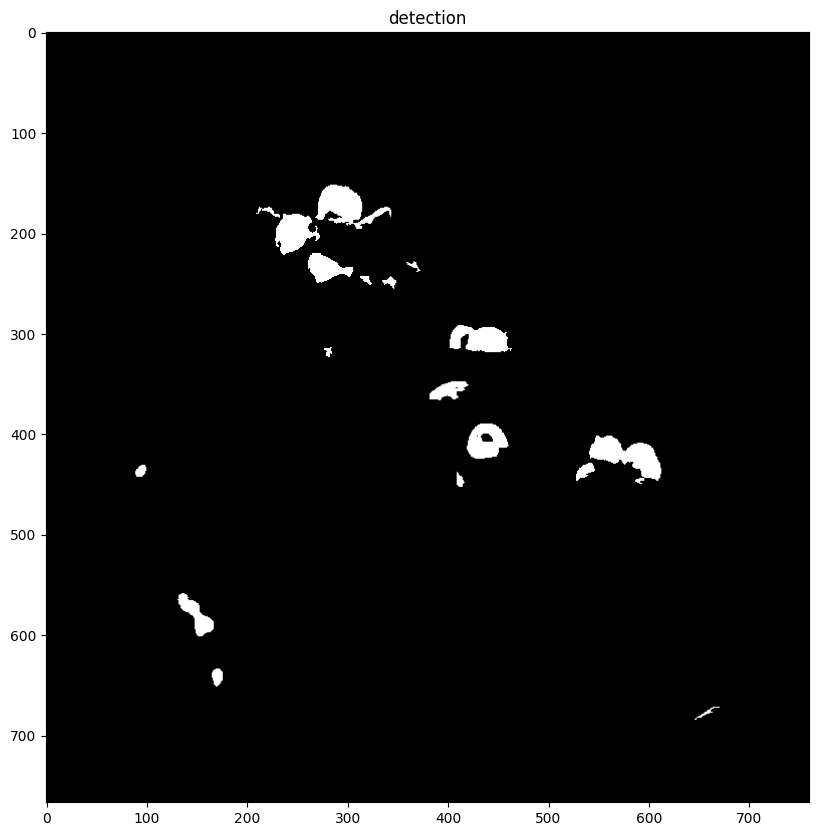

In [8]:
from skimage import morphology
S = morphology.remove_small_objects(D, min_size=40, connectivity=2)
plt.figure(figsize=(10,10))
plt.imshow(S,cmap='gray')
plt.title('detection')
plt.show()


In [9]:
from skimage.morphology import binary_dilation
from skimage.segmentation import clear_border


from skimage.color import label2rgb
from skimage.measure import label

def binview(img, mask, color='r', dilate_pixels=1):
    """
    Displays a gray or color image 'img' overlaid by color pixels determined a by binary image 'mask'. It is useful to
    display the edges of an image.

    Args:
        img: gray scale image (X-ray)
        mask: binary image that works as mask
        color: string to define pixel color.
                'r': red (default)
                'g': green
                'b': blue
                'y': yellow
                'c': cyan
                'm': magenta
                'k': black
                'w': white

        dilate_pixels (int): Number of pixels used for dilate the mask.

    Returns:
        img_color (ndarray): output image with a mask overlaid.
    """

    # Defines colors
    # colors = {
    #     'r': np.array([255, 0, 0]),
    #     'g': np.array([0, 255, 0]),
    #     'b': np.array([0, 0, 255]),
    #     'y': np.array([255, 255, 0]),
    #     'c': np.array([0, 255, 255]),
    #     'm': np.array([255, 0, 255]),
    #     'k': np.array([0, 0, 0]),
    #     'w': np.array([255, 255, 255])
    # }
    #
    colors = {
        'r': np.array([1, 0, 0]),
        'g': np.array([0, 1, 0]),
        'b': np.array([0, 0, 1]),
        'y': np.array([1, 1, 0]),
        'c': np.array([0, 1, 1]),
        'm': np.array([1, 0, 1]),
        'k': np.array([0, 0, 0]),
        'w': np.array([1, 1, 1])
    }
    # Create a RGB image from grayscale image.
    img_color = np.dstack((img, img, img))

    # Ensure do not modify the original color image and the mask
    img_color = img_color.copy()

    mask_ = mask.copy()
    # mask_ = dilate(mask_, np.ones((g, g), np.uint8))
    mask_ = binary_dilation(mask_, np.ones((dilate_pixels, dilate_pixels)))

    # Now black-out the area of the mask
    # img_fg = bitwise_and(img, img, mask=mask_)

    # Defines the pixel color used for the mask in the figure.
    cc = colors[color]
    #
    # for i in range(3):
    #     img_color[:, :, i] = cc[i] * img_fg

    # remove artifacts connected to image border
    cleared = clear_border(mask_)
    if np.all(cleared):
        mask_ = cleared

    # label image regions
    label_image = label(mask_)
    img_color = label2rgb(label_image, image=img_color, colors=[cc], bg_label=0)

    return img_color  # add(img_color, img_color)


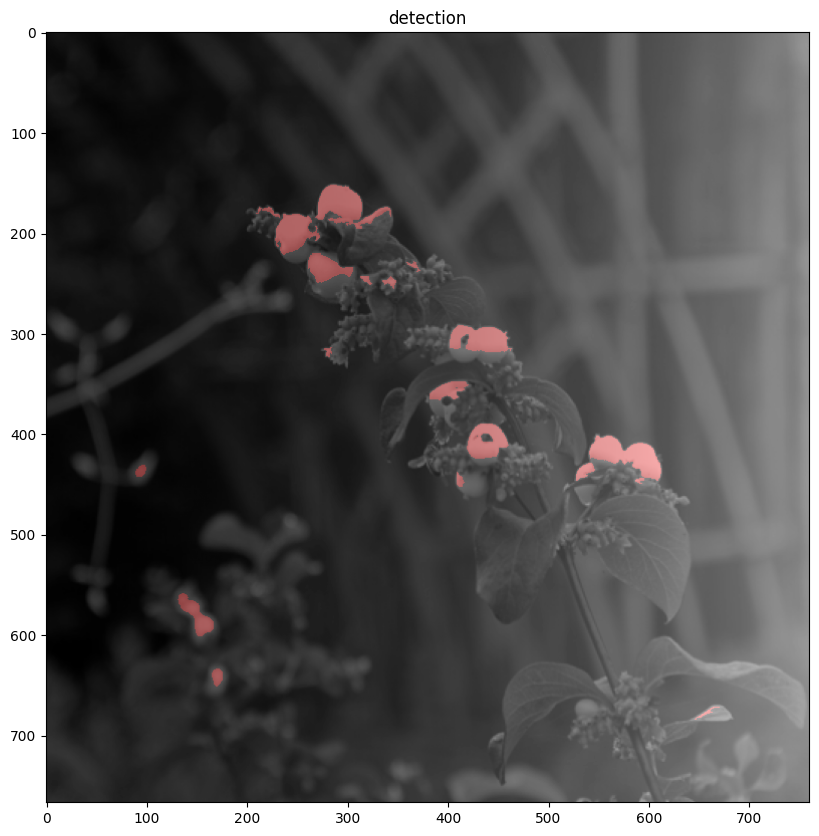

In [10]:
blend_mask = binview(X, S, 'r', 1)

plt.figure(figsize=(10,10))
plt.imshow(blend_mask,cmap='gray')
plt.title('detection')
plt.show()



**Bibliografía**  
D. Mery. Fundamentos de Procesamiento de Imágenes Departamento de Ciencia de la Computación. Universidad Católica de Chile, 2024.

Ejercicios:
2) Trabaja con la imagen de los frutos y aplica los filtros y operaciones vistas en esta notebook (apertura, filtro mediana, diferencia/tophat, umbralizado y limpieza morfologica) para binarizar la imagen delimitando los frutos.


### Consigna 2 - Binarizacion de la imagen de los frutos

Se aplica el **filtro mediana** para eliminar ruido, la **apertura** con elemento estructurante
grande para estimar el fondo, la **diferencia (TOPHAT)** para resaltar los frutos, un
**umbralizado** para obtener la mascara binaria y una **limpieza morfologica** para delimitar
cada fruto por separado.


In [ ]:
# --- 1) Filtro MEDIANA sobre la imagen de los frutos (X ya fue leida) ---
k = 5
Xm = cv2.medianBlur(X, k)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(X, cmap='gray'); plt.title('original'); plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(Xm, cmap='gray'); plt.title(f'filtro mediana {k}x{k}'); plt.axis('off')
plt.show()


In [ ]:
# --- 2) Estimacion del fondo (apertura) y TOPHAT (diferencia) ---
n = 120
ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (n, n))
Xe = cv2.morphologyEx(Xm, cv2.MORPH_OPEN, ker)
Xd = Xm.astype(float) - Xe.astype(float)

plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
plt.imshow(Xm, cmap='gray'); plt.title('con mediana'); plt.axis('off')
plt.subplot(1, 3, 2)
plt.imshow(Xe, cmap='gray'); plt.title(f'fondo (apertura n={n})'); plt.axis('off')
plt.subplot(1, 3, 3)
plt.imshow(Xd, cmap='gray'); plt.title('TOPHAT = X - apertura'); plt.axis('off')
plt.show()


In [ ]:
# --- 3) Binarizacion ---
th = 80
D = Xd > th
D = morphology.remove_small_objects(D, min_size=40, connectivity=2)

plt.figure(figsize=(8, 8))
plt.imshow(D, cmap='gray')
plt.title(f'umbral = {th}')
plt.show()


In [ ]:
# --- 4) Limpieza: relleno de huecos + eliminacion de objetos pequenos ---
from scipy.ndimage import binary_fill_holes

D = binary_fill_holes(D)
D = morphology.remove_small_objects(D, min_size=150, connectivity=2)

frutos = label(D)
n_frutos = frutos.max()
areas = np.bincount(frutos.ravel())[1:]
print(f'frutos delimitados = {n_frutos}')
print('areas (px) =', sorted(areas, reverse=True))

plt.figure(figsize=(8, 8))
plt.imshow(D, cmap='gray')
plt.title(f'mascara final - {n_frutos} frutos')
plt.show()


In [ ]:
# --- 5) Overlay de la mascara sobre la imagen original ---
blend = binview(X, D, 'r', 1)

plt.figure(figsize=(8, 8))
plt.imshow(blend)
plt.title(f'frutos delimitados - {n_frutos} frutos')
plt.show()
